load cleand and EDA complete dataset

In [3]:
import pandas as pd

PE = pd.read_csv("fitness_classes_EDA.csv")



In [4]:
PE

,ActivitySiteID,ActivityDescription,BookingEndDate,BookingStartTime,MaxBookees,Number Booked,Price (INR),Month,Day,Hour,TimeSlot,Occupancy Rate,Revenue
0,BRP,20:20:20 9.30-10.30am,01-06-18,01-01-00 9:30,35,28,499,June,Friday,9,Morning,80.000000,13972
1,BRP,20:20:20 9.30-10.30am,08-06-18,01-01-00 9:30,35,35,499,June,Friday,9,Morning,100.000000,17465
2,BRP,20:20:20 9.30-10.30am,15-06-18,01-01-00 9:30,35,31,499,June,Friday,9,Morning,88.571429,15469
3,BRP,20:20:20 9.30-10.30am,22-06-18,01-01-00 9:30,35,32,499,June,Friday,9,Morning,91.428571,15968
4,BRP,20:20:20 9.30-10.30am,29-06-18,01-01-00 9:30,35,19,499,June,Friday,9,Morning,54.285714,9481
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3284,NBL,Zumba Gold 12.45-1.45pm,01-05-18,01-01-00 12:45,60,47,1999,May,Tuesday,12,Afternoon,78.333333,93953
3285,NBL,Zumba Gold 12.45-1.45pm,08-05-18,01-01-00 12:45,60,42,1999,May,Tuesday,12,Afternoon,70.000000,83958
3286,NBL,Zumba Gold 12.45-1.45pm,15-05-18,01-01-00 12:45,60,38,1999,May,Tuesday,12,Afternoon,63.333333,75962
3287,NBL,Zumba Gold 12.45-1.45pm,22-05-18,01-01-00 12:45,60,39,1999,May,Tuesday,12,Afternoon,65.000000,77961


 Select Features and Target

In [5]:
#Target y
y = PE["Number Booked"]

In [6]:
#Feature x
x = PE[[
    "Price (INR)",
    "MaxBookees",
    "Hour",
    "TimeSlot",
    "Month",
    "Day",
    "ActivitySiteID",
    "ActivityDescription"
]]

In [7]:
#Check Missing Values
y.isnull().sum()

np.int64(0)

In [8]:
x.isnull().sum()

Price (INR)            0
MaxBookees             0
Hour                   0
TimeSlot               0
Month                  0
Day                    0
ActivitySiteID         0
ActivityDescription    0
dtype: int64

In [9]:

x.dtypes

Price (INR)            int64
MaxBookees             int64
Hour                   int64
TimeSlot                 str
Month                    str
Day                      str
ActivitySiteID           str
ActivityDescription      str
dtype: object

In [17]:
"""Categorical Feature Encoding
Categorical variables were transformed using One-Hot Encoding to convert text-based categories into numerical features suitable
 for regression modeling."""
X = pd.get_dummies(
    x,
    columns=[
        "TimeSlot",
        "Month",
        "Day",
        "ActivitySiteID",
        "ActivityDescription"
    ],
    drop_first=True
)

In [18]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [20]:
#Train the Linear Regression Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](296,)","[ -0. , 0.31, 1.64,...,-14.11, -8.97, 10.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](296,)","['Price (INR)','MaxBookees','Hour',..., 'ActivityDescription_Zumba 9.30-10.30am', 'ActivityDescription_Zumba Gold 1.45-2.45pm', 'ActivityDescription_Zumba Gold 12.45-1.45pm']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-14.42
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,296
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(292)


In [22]:
#Make Predictions
y_pred = model.predict(X_test)

In [ ]:
#Compare actual and predicted
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
2213,8,8.310251
2772,13,7.878969
1660,27,29.751228
1656,27,26.972755
3241,19,21.371268
3032,22,22.125020
554,14,11.559960
238,11,13.195998
1171,26,30.374060
2896,26,22.274538


In [ ]:
#Calculate R² Score, MSE and RMSE
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R² Score :", round(r2, 4))
print("MSE      :", round(mse, 4))
print("RMSE     :", round(rmse, 4))

R² Score : 0.7858
MSE      : 19.2969
RMSE     : 4.3928


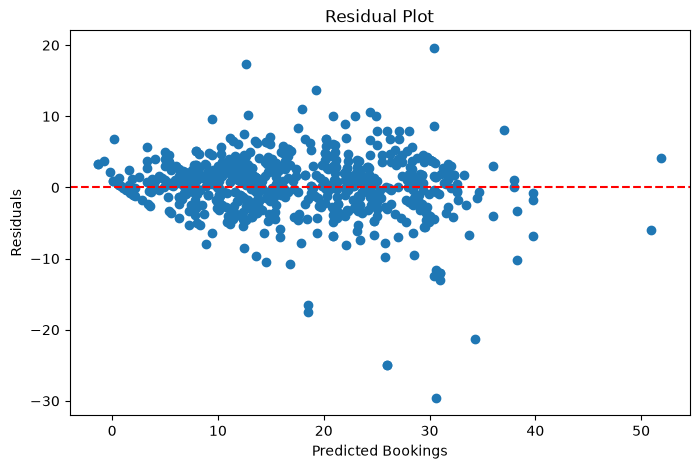

In [ ]:
#Residual Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.scatter(y_pred, y_test - y_pred)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Bookings")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()